In [1]:
from qiskit.quantum_info import Operator

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import numpy as np
import scipy

## Task 1

In [2]:
# circuit parameters
Q = 2
q0 = 0 # control qubit
q1 = 1 # defeat qubit


gamma0 = 0 # classical PD
gamma1 = np.pi/2 # quantum PD

In [3]:
D = np.array([[0, 1], [-1, 0]]) # Defect
Q_operator = np.array([[1j, 0], [0, -1j]]) # Quantum move

# cooperate is the identity

In [4]:
def J_num(gamma):
    return scipy.linalg.expm( -1j * gamma/2 * np.kron(D, D))

In [5]:
def J_gates(gamma):    
    qc_gates = QuantumCircuit(Q) 

    qc_gates.cx(q0,q1)
    qc_gates.cz(q0,q1)

    qc_gates.rx(gamma, q0)

    qc_gates.cz(q0,q1)
    qc_gates.cx(q0,q1)

    fig = qc_gates.draw("mpl")

    return Operator(qc_gates), fig

In [6]:
def J_gates_hermit(gamma):    
    qc_gates = QuantumCircuit(Q) 

    qc_gates.cx(q0,q1)
    qc_gates.cz(q0,q1)

    qc_gates.rx(-gamma, q0)

    qc_gates.cz(q0,q1)
    qc_gates.cx(q0,q1)

    fig = qc_gates.draw("mpl")

    return Operator(qc_gates), fig

In [7]:
J_num_qpd = J_num(gamma1)
J_gates_qpd, circuit_plot = J_gates(gamma1)

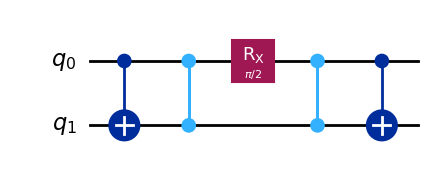

In [8]:
circuit_plot

In [9]:
np.allclose(J_num_qpd, J_gates_qpd)

True

## Task 2

In [10]:
def J_gates(gamma):    
    qc_gates = QuantumCircuit(Q) 

    qc_gates.cx(q0,q1)
    qc_gates.cz(q0,q1)

    qc_gates.rx(gamma, q0)

    qc_gates.cz(q0,q1)
    qc_gates.cx(q0,q1)


    return qc_gates


def J_gates_hermit(gamma):    
    qc_gates = QuantumCircuit(Q) 

    qc_gates.cx(q0,q1)
    qc_gates.cz(q0,q1)

    qc_gates.rx(-gamma, q0)

    qc_gates.cz(q0,q1)
    qc_gates.cx(q0,q1)


    return qc_gates

In [11]:
def QPD_circuit(gamma, U_A, U_B):
    qc = QuantumCircuit(Q) 
    
    qc.append(J_gates(gamma), [q0, q1])
    
    # Apply players' strategies
    qc.append(U_A, [q0])
    qc.append(U_B, [q1])
    
    # Apply J-dagger gate
    qc.append(J_gates_hermit(gamma), [q0, q1])

    qc.measure_all()
    
    return qc

In [15]:
from qiskit.primitives import StatevectorSampler as Sampler

def run_QPD(circuit, N=100000, r=3, t=5, s=0, p=1):
    
    sampler = Sampler()
    job = sampler.run([circuit], shots=N)
    result = job.result()

    counts = result[0].data.meas.get_counts()
    
    P_CC = counts.get('00', 0) / N
    P_CD = counts.get('01', 0) / N
    P_DC = counts.get('10', 0) / N
    P_DD = counts.get('11', 0) / N

    #print(f"P(CC)={P_CC:.3f}, P(CD)={P_CD:.3f}, P(DC)={P_DC:.3f}, P(DD)={P_DD:.3f}")

    payoff_A = r * P_CC + t * P_DC + s * P_CD + p * P_DD
    
    return payoff_A

In [19]:
def generate_plots_for_strategies(U_A, U_B, title, ax):
    angles = np.linspace(0, np.pi/2, 50)
    payoff_A_all = []
    
    for i in angles:
        qpd_circuit = QPD_circuit(i, U_A, U_B)
        payoff_A = run_QPD(qpd_circuit) 
        payoff_A_all.append(payoff_A)
    
    ax.plot(angles, payoff_A_all, label=title)
    ax.set_xlabel('Angle (rad)')
    ax.set_ylabel('Payoff Player A')
    ax.grid(True)
    ax.legend()

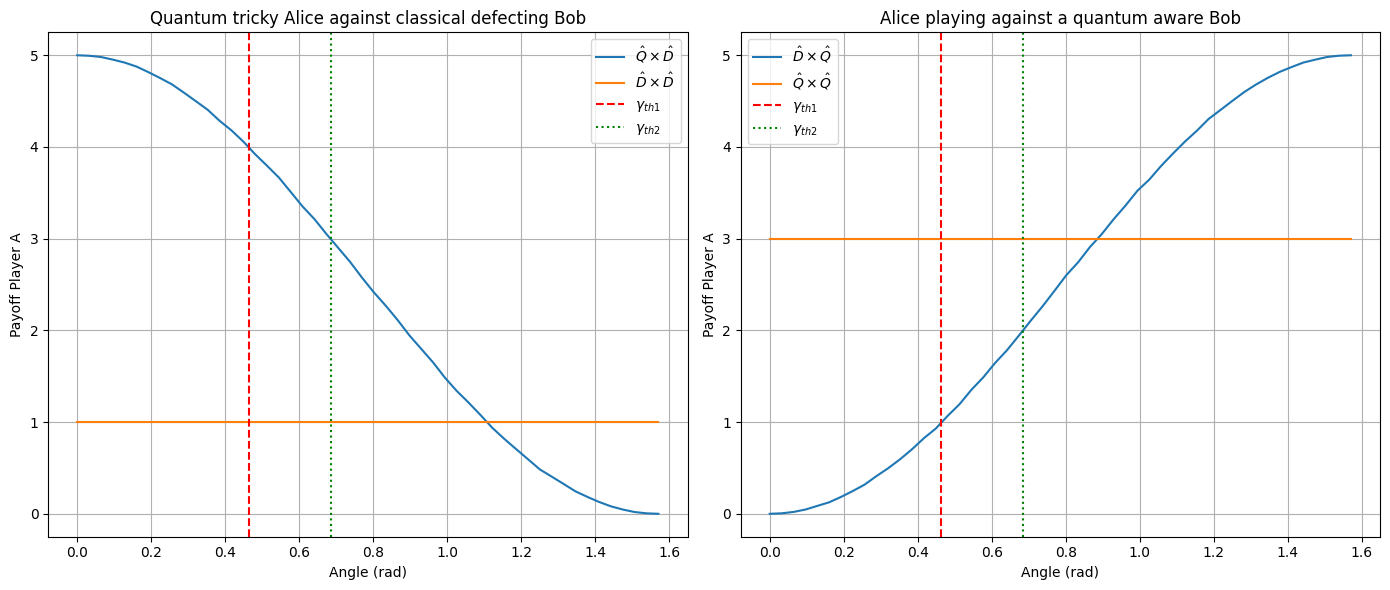

In [22]:
from qiskit.circuit.library import YGate, ZGate

D_gate = YGate()
Q_gate = ZGate()

def plot_task_2():
    _ , axs = plt.subplots(1, 2, figsize=(14, 6))
    
    generate_plots_for_strategies(Q_gate, D_gate, r'$\hat{Q} \times \hat{D}$', axs[0])
    generate_plots_for_strategies(D_gate, D_gate, r'$\hat{D} \times \hat{D}$', axs[0])
    axs[0].set_title('Quantum tricky Alice against classical defecting Bob')
    
    generate_plots_for_strategies(D_gate, Q_gate, r'$\hat{D} \times \hat{Q}$', axs[1])
    generate_plots_for_strategies(Q_gate, Q_gate, r'$\hat{Q} \times \hat{Q}$', axs[1])
    axs[1].set_title('Alice playing against a quantum aware Bob')

    gamma_th1 = np.arcsin(np.sqrt(1/5))
    gamma_th2 = np.arcsin(np.sqrt(2/5))

    for ax in axs:
        ax.axvline(x=gamma_th1, color='red', linestyle='--', label=r'$\gamma_{th1}$')
        ax.axvline(x=gamma_th2, color='green', linestyle=':', label=r'$\gamma_{th2}$')
        
        ax.legend()
        
    plt.tight_layout()
    plt.show()


plot_task_2()